LangGraph is a powerful library built on top of LangChain that focuses on creating stateful, multi-agent workflows using a graph structure. Let's start with the fundamental structure of LangGraph. We'll build a simple agent that just calls the LLM without any external tools. This helps understand the core concepts: State, Nodes, and Edges.

Key Components of LangGraph

- **StateGraph:** The core object for building workflows
- **Nodes:** Functions or agents that perform specific tasks
- **Edges:** Connections between nodes that control flow
- **State:** Information that persists across nodes
- **Conditional Routing:** Logic for determining which path to follow

In [1]:
# Install necessary libraries
# We need langchain, langgraph, openai integration, tavily, requests, and gradio
%pip install -q --upgrade langchain langgraph langchain_openai tavily-python python-dotenv gradio langchain_community graphviz requests
# tavily is used for searching the net, RapidAPI is used for hotel search

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
crewai 1.14.2 requires python-dotenv~=1.1.1, but you have python-dotenv 1.2.2 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import necessary libraries
import os
import uuid
import getpass
from typing import TypedDict, Annotated, Sequence, List, Tuple, Optional, Any, Union, Literal,  Tuple
import operator
from datetime import date
from IPython.display import display, Markdown, Image
from graphviz import Source
import uuid  # Added for Gradio state

# Langchain specific imports
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage, ToolMessage, HumanMessage, AIMessage, SystemMessage
from langchain.tools import tool
from pydantic import BaseModel  # For tool args schema if needed explicitly
# LangGraph imports (Updated based on recent versions)
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode  # Preferred way to handle tool execution

# Gradio
import gradio as gr

# Load environment variables
from dotenv import load_dotenv
load_dotenv()

# Set environment variables (especially useful for LangChain integrations)
openai_api_key = os.environ["OPENAI_API_KEY"]

print("API Keys loaded (partially hidden for security):")
print(f"OpenAI Key starts with: {openai_api_key[:5]}...")


c:\Users\Cleaven Dcosta\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


API Keys loaded (partially hidden for security):
OpenAI Key starts with: sk-pr...


In [3]:
# Helper function to display markdown nicely
def print_markdown(text):
    """Displays text as Markdown in Jupyter."""
    display(Markdown(text))

In [4]:
#  define a simple workflow that includes a summarization function
#  define a state that includes two information: the original text and its summary
# State is how information persists and flows between nodes
# The state is like a container that stores and passes data between different parts of our workflow
# Each node receives and returns a state object, and the State can include messages, variables, memory, etc.

class AgentState(TypedDict):
    input_text:str
    summary:str
#our state here will be dictionary passed bw various nodes

In [5]:
# Let's define the key node, which represents the functions that perform specific tasks in your graph
# They receive the current state and return a modified state
# Note that a node can be simple functions, LLM calls, or complex agents
#remember, Nodes are functions

def summarize_step(state: AgentState) -> AgentState:  #node takes a state and returns a state
    """Create a concise sumary of the input text"""
    llm = ChatOpenAI(model="gpt-3.5-turbo")
    prompt = f"Please summarize the following text in one sentence that captures the main points: {state['input_text']}"

    #Get summary directly from model
    result = llm.invoke(prompt)

    #Update state with our summary
    return {
        "input_text": state["input_text"],
        "summary":result.content
    }

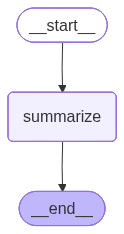

In [6]:
#  define  StateGraph, which is the fundamental building block of LangGraph
# It manages the flow of information between different components
# It maintains state throughout the execution of your workflow

# Let's define a stategraph with the "AgentState" we defined earlier
workflow = StateGraph(AgentState)

# Let's add a node, which is the summarize function we defined before
workflow.add_node("summarize", summarize_step)

# Let's define Edges, which define how data flows between nodes
workflow.add_edge("summarize", END) 
workflow.set_entry_point("summarize") #entry point is the summarize step
workflow.compile() #compile the full thing

In [7]:
#  execute the graph 
# After defining your graph, you need to compile it to create an executable workflow
# Invoke it with an initial state to run the entire process

# Example text to summarize
sample_text = """
    Electric cars work by using electricity stored in a battery pack to power an electric motor, which drives the wheels. 
    Unlike gasoline-powered vehicles that rely on internal combustion engines, electric vehicles (EVS) use electric motors that are more efficient and produce zero emissions during operation. 
    When you press the accelerator, the battery sends power to the motor, which instantly provides torque to move the car. 
    The battery is recharged by plugging the car into an external power source, such as a home charger or public charging station. 
    Some electric cars also feature regenerative braking, which captures energy during braking and feeds it back into the battery to improve efficiency.
    """
    
# Let's compile the graph
graph = workflow.compile() 

# Set up the initial state with the input text
initial_state = {
        "input_text": sample_text,
        "summary": ""}
    
# Run the graph
result = graph.invoke(initial_state)
    
# Get the summary from the result
summary = result["summary"]
    
# Print the result
print(summary)

Electric cars use electricity stored in a battery to power an electric motor, which is more efficient and produces zero emissions, and the battery is recharged by plugging the car into an external power source.


# BUILD AN AGENTIC WORKFLOW IN LANGGRAPH (SUMMARIZATION + TRANSLATION AGENT) WITH NO TOOLS

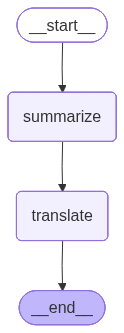

In [28]:
class AgentState(TypedDict):
    input_text:str
    summary:str
    translated_summary:str

def translate_step(state: AgentState)->AgentState:
    """Translate the summary"""

    llm = ChatOpenAI(model="gpt-3.5-turbo")
    prompt = f"Please translate the following summary into Spanish: {state['summary']}"

    result = llm.invoke(prompt)

    return{
        "input_text": state["input_text"],
        "summary": state["summary"],
        "translated_summary": result.content
    } 
    

#define the workflow
workflow = StateGraph(AgentState)
workflow.add_node("summarize", summarize_step)
workflow.add_edge("summarize", "translate")
workflow.add_node("translate", translate_step)
workflow.add_edge("translate", END)
workflow.set_entry_point("summarize")
workflow.compile()


In [9]:
# Example text to summarize
sample_text = """
    Electric cars are awesome! I love them so much! They work by using electricity stored in a battery pack to power an electric motor, which drives the wheels. 
    Unlike gasoline-powered vehicles that rely on internal combustion engines, electric vehicles (EVS) use electric motors that are more efficient and produce zero emissions during operation. 
    When you press the accelerator, the battery sends power to the motor, which instantly provides torque to move the car. 
    The battery is recharged by plugging the car into an external power source, such as a home charger or public charging station. 
    Some electric cars also feature regenerative braking, which captures energy during braking and feeds it back into the battery to improve efficiency.
    """
    
graph = workflow.compile()

initial_state = {
        "input_text": sample_text,
        "summary": "",
        "translated_summary": ""
    }
#run graph
result = graph.invoke(initial_state)

# Get the summary from the result, note we r returning dictionaries, as stat is a dict which persists throughout the graph
summary = result["summary"]
translation = result["translated_summary"]

# Print the results with clear labels and spacing
print("=== Generated Summary ===")
print(summary)

print("\n=== Translated Summary ===")
print(translation)

=== Generated Summary ===
Electric cars are efficient, produce zero emissions, and are recharged by plugging into an external power source, with some models using regenerative braking to improve efficiency.

=== Translated Summary ===
Los coches eléctricos son eficientes, no producen emisiones y se recargan conectándolos a una fuente de energía externa, con algunos modelos que utilizan frenado regenerativo para mejorar la eficiencia.


# LANGGRAPH WITH SINGLE TOOL (WEB SEARCH) USING TOOLNODE & CONDITIONAL EDGE


Now, let's give our agent its first superpower: the ability to search the web using the Tavily tool. We'll `ToolNode` for handling tool execution.

**Changes:**

1.  **Tool Definition:** Define the `tavily_search_tool`.
2.  **Nodes:**
    *   Define `call_model_with_tools` node that binds the tool(s) to the LLM.
    *   Instantiate `ToolNode`: Create an instance of `ToolNode` with our list of tools.
3.  **Conditional Edge:** Use the `should_continue` function (which checks the last message for tool calls) to direct the flow.
4.  **Graph Construction:**
    *   Add the `call_model_with_tools` node ("agent").
    *   Add the instantiated `ToolNode` as the "action" node.
    *   Set the entry point to "agent".
    *   Add the conditional edge from "agent" based on `should_continue` to either "action" or `END`.
    *   Add a direct edge from "action" back to "agent".

So basically, what we do over here is, initially what we do is we redefine the, we bind the tool, that is a predefined tool, that is a Tevaly search tool, to our LLM. And after binding it, we set a conditional edge. Okay, what we're gonna do is we're gonna set a conditional edge wherein if required, then we can instantiate that tool, meaning, make a call to that tool, use that tool. Okay, for example, Tevaly search tool, we can search the web with our LLM. Okay, and that is how the two nodes are there that is going to be defined earlier, as mentioned in the markdown.


In [10]:
from dotenv import load_dotenv
load_dotenv()
tavily_api_key = os.environ["TAVILY_API_KEY"]
print(f"Tavily Key starts with: {tavily_api_key[:5]}...")

Tavily Key starts with: tvly-...


In [36]:
# Define the Agent State
class AgentState(TypedDict):
    # AgentState is the name of the dictionary (used to represent the agent's state in the workflow).
    # It has one key: "messages", which holds a list of messages (e.g., from the user, model, or tools).
    # BaseMessage is the type used to represent each message in that list.
    # operator.add tells LangGraph to append new messages to the list during execution.
    messages: Annotated[Sequence[BaseMessage], operator.add]

#basically we r doin this annotated way to append the messages by the llm , or the functions, or by tavily everytime, so we can see what work is being done

In [37]:
#Let's set up our search tool that fetches results from Tavily (a search engine wrapper)
# Setting max_results to 3 limits the number of search results.

from langchain_community.tools.tavily_search import TavilySearchResults

tavily_search_tool = TavilySearchResults(max_results = 3)

# List of tools for this step
tools_list_single = [tavily_search_tool]

In [45]:
#  define call_model_with_tools node that binds the tool(s) to the LLM.
# This format is useful when you want to reuse the same model logic with different tools.
# You're building modular, reusable parts for your AI workflow (like LangGraph nodes).
# The Outer function (make_call_model_with_tools(tools)):
# It knows about the tools and returns a customized inner function.

# Inner function (call_model_with_tools(state)): This is the execution function. 
# It knows how to use the current state (conversation history) and actually runs the model with the tools that were set up by the outer function.

from langchain_openai import ChatOpenAI
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

def make_call_model_with_tools(tools: list):   #set tool list to bind to llm
    def call_model_with_tools(state: AgentState): #llm
            print("DEBUG: Entering call_model_with_tools node")
            messages = state["messages"]

            #Binds tools to language model
            model_with_tools = llm.bind_tools(tools)    

            #Feeds convo history(messages) into the model
            response = model_with_tools.invoke(messages)

            #return the model response as a new message
            return {
                  "messages": [response]
            }
    return call_model_with_tools 

In [46]:
# Define Conditional Edge Logic
# This function checks the most recent message in the state and decides whether to route to the 'action' node (ToolNode) or end.
# This function is used to control the flow of your agent, it's like a traffic signal deciding where to send the agent next.
# The function should_continue checks the last message in the agent's memory and decides:
# If the message includes a tool call, it routes to the next step (the action node, where the tool is actually used).
# If there's no tool call, it ends the conversation (__end__).

def should_continue(state: AgentState)->Literal["action", "__end__"]:
    """Determines the next step: continue with tools or not"""
    print("DEBUG: Entering should_continue node")
    last_message = state["messages"][-1] #we check the last message, if it involves any word regarding tools, then we go to the action step else end

    #Check if last message is an AIMessage weith tool calls
    if isinstance(last_message, AIMessage) and hasattr(last_message, "tool_calls") and last_message.tool_calls:
        print("DEBUG: Decision: continue (route to action)")
        return "action"  # Route to the node named "action"
    else:
        print("DEBUG: Decision: end (route to END)")
        return END  # Special value indicating the end of the graph


In [47]:
# ToolNode is a prebuilt ready-to-use node from LangGraph that is specifically designed to run external tools 
# like search, calculator, database query
#we will use it here to run the tool of tailvy to search the web
from langgraph.prebuilt import ToolNode  

def build_graph_one_tool(tools_list):

    #Instantiate Tool Node
    tool_node = ToolNode(tools_list)

    #Bind the toolnode to the LLM thru the function call
    call_node_fn =make_call_model_with_tools(tools_list)

    #Build the graph
    graph_one_tool = StateGraph(AgentState)

    graph_one_tool.add_node("agent", call_node_fn)
    graph_one_tool.add_node("action", tool_node)
    graph_one_tool.set_entry_point("agent")

     # Add a conditional edge from the agent
    # The dictionary maps the return value of 'should_continue' ("action" or END)
    # to the name of the next node ("action" or the special END value).
    graph_one_tool.add_conditional_edges(
        "agent", #source node
        should_continue, #function to decide the route
        {"action": "action", END: END} # Mapping: {"decision": "destination_node_name"}
    )
    #add node from the action back to the agent
    graph_one_tool.add_edge("action", "agent")

    #Compile the graph
    app = graph_one_tool.compile()

    #Visualize
    display(Image(app.get_graph().draw_mermaid_png()))
  
    return app


In [48]:
#Main function to perform operation
def app_call(app, messages):
    # Initialize the state with the provided messages
    initial_state = {"messages": [HumanMessage(content=messages)]}

    # Invoke the app with the initial state
    final_state = app.invoke(initial_state)

    # Iterate through the messages in the final state
    for i in final_state["messages"]:
        # Print the type of the message in markdown format
        print_markdown(i.type)
        # Print the content of the message in markdown format
        print_markdown(i.content)
        # Print any additional kwargs associated with the message
        if i.additional_kwargs != {}:
            print(i.additional_kwargs)

    # Return the content of the last message and the final state
    return final_state["messages"][-1].content, final_state

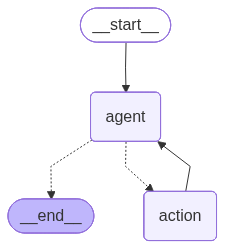

In [49]:
app = build_graph_one_tool(tools_list_single)

In [50]:
messages = "What's the latest news on France in May 2025? Is it a good time to visit?"
output, history = app_call(app, messages)

print("\n==================== OUTPUT ====================")
print(output)

print("\n==================== HISTORY ===================")
print(history)

DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


human

What's the latest news on France in May 2025? Is it a good time to visit?

ai

{'refusal': None}


tool

[{"title": "Information | The Best Events & Destinations to Visit by Car in France This May 2025", "url": "https://www.emovis-tag.co.uk/articles/information/May.2025.France", "content": "8. European Museum Night (May 17, 2025): Experience culture after dark as over 1,200 French museums open their doors for free from 6 pm to midnight. Enjoy special events, storytelling tours, screenings, and fireworks across various cities.\n\n9. Jazz Sous les Pommiers in Coutances (May 24-31, 2025): Head to Normandy for the 'Jazz Under the Apple Trees' festival, featuring performances from established and emerging jazz artists. The event includes street performances and a variety of jazz styles, from New Orleans to electronic fusion. [...] 4. Gypsy Pilgrimage to Les Saintes Maries de la Mer (May 23-25, 2025): Immerse yourself in the rich traditions of the Romany community during their annual pilgrimage to Les Saintes Maries de la Mer in the Camargue region. The event features religious ceremonies, music, parades, and vibrant celebrations honouring Saint Sara-la-Kali.\n\n5. Roland Garros in Paris (May 19-June 8, 2025): For tennis enthusiasts, attending the French Open at Roland Garros is a must. Witness top players compete on the iconic clay courts in one of the sport's most prestigious tournaments. [...] 2. Monaco Grand Prix (May 22-25, 2025): Experience the thrill of Formula 1 racing at the Monaco Grand Prix. The event features free trials and qualifiers in the initial days, culminating in the main race on May 25.\n\n3. Nuits Sonores in Lyon (May 28-June 1, 2025): Lyon hosts the Nuits Sonores festival, a celebration of electronic and independent music. Held in unique venues across the city, including museums and disused factories, the festival offers a blend of music, contemporary art, exhibitions, and films.", "score": 0.9436445}, {"title": "2025 in France - Wikipedia", "url": "https://en.wikipedia.org/wiki/2025_in_France", "content": "25 May – A second suspected arson attack on an electricity substation in Nice causes a blackout that affects 45,000 homes in the city as well as in Saint-Laurent-du-Var and Cagnes-sur-Mer.\n 28 May – Surgeon and convicted paedophile Joël Le Scouarnec is sentenced to 20 years' imprisonment for abusing 299 patients including children from 1989 to 2014.\n 31 May –\n  + Paris Saint-Germain defeats Inter Milan 5-0 to win the UEFA Champions League for the first time. Following this, two people are killed in incidents in Dax and Paris during victory celebrations, while a police officer is severely injured in a related incident in Coutances. At least 294 others are arrested.\n  + A Tunisian national is shot dead in a suspected hate crime in Puget-sur-Argens. [...] 17 May – France's Louane \"Louane (singer)\") finishes in seventh place at Eurovision 2025 in Switzerland with the single \"Maman \"Maman (2025 song)\")\".\n 18 May – An air traffic control systems failure causes massive disruptions at Paris-Orly Airport.\n 20 May – Three people are killed in adverse conditions caused by thunderstorms in Le Lavandou and Vidauban.\n 24 May –\n  + A suspected arson attack on an electricity substation in Tanneron causes a blackout that affects 160,000 homes in Alpes-Maritimes, including in Cannes.\n  + Iranian film director Jafar Panahi wins the Palme d'Or at the 2025 Cannes Film Festival for his film It Was Just an Accident. [...] 50. ^ \"Dissident Iranian filmmaker Panahi wins Cannes top prize\". France 24. 24 May 2025. Retrieved 25 May 2025.\n51. ^ \"Second suspected sabotage in France as power cut hits Nice\". BBC. 25 May 2025. Retrieved 26 May 2025.\n52. ^ \"French paedophile surgeon who abused hundreds sentenced to 20 years in jail\". BBC. 28 May 2025. Retrieved 28 May 2025.\n53. ^ \"Doué double leads PSG thrashing of Inter Milan for first Champions League trophy\". AP News. 31 May 2025. Retrieved 1 June 2025.\n54. ^ \"2 fans died and an officer is in a coma after Champions League celebrations in France\". AP News. 1 June 2025. Retrieved 1 June 2025.\n55. ^ \"France opens terror case after Tunisian hairdresser shot dead in 'racist act'\". The Guardian. 3 June 2025. Retrieved 3 June 2025.", "score": 0.9358233}, {"title": "Everything that changes in France in May 2025", "url": "https://www.thelocal.fr/20250422/everything-that-changes-in-france-in-may-2025", "content": "Gas prices decrease\n\nThere is some good news for households who heat with gas. Starting on May 1st, the reference price per kilowatt-hour (kWh) will decrease by 6.4 percent, from €0.12412 to €0.1162.\n\nThis means that households who heat with gas would see an average saving of €90 a year, assuming they consume the standard amount (11,500kWh per year). In this case, their annual bill would drop from an average of €1,427 to €1,336.\n\nFor households who use gas solely for cooking or heating water, their reference price is also set to fall from €0.1530 to €0.1451 per kWh, representing a decrease of 5.12 percent.\n\nBenefits increased to reflect inflation [...] Roland-Garros tennis tournament\n\nThe French Open begins on Sunday, May 25th and it will run until Sunday, June 8th. You can see the provisional schedule on the Roland-Garros website.\n\nImpending deadline for VAT rule changes\n\nFrance's 2025 budget, which passed in February, included a new VAT threshold for all businesses, which would force many self-employed people (micro entrepreneurs) into paying VAT for the first time.\n\n### Advertisement\n\nThis change has been controversial, and within hours of the budget being passed, it was announced the VAT reform would be paused until at least the end of May.\n\nREAD MORE: France’s micro-entrepreneurs in limbo over changes to VAT rules\n\nNew flights [...] The Cannes Film Festival\n\nThe 78th edition of the Cannes film festival will take place from May 13th to 24th at the Palais des festivals et des congrès in Cannes. This year, during the opening ceremony, the Honorary 'Palme d'Or' will be awarded to Robert De Niro.\n\nEurovision\n\n### Advertisement\n\nYou can watch France compete in the Eurovision song contest in Basel, Switzerland this year. The semi-finals are set for May 13th and May 15th (although France goes straight through to the finals every year as one of the 'big five' who fund the contest). The final is on Saturday, May 17th. France will be represented by the singer Louane.\n\nREAD MORE: 5 things to know about Louane, Maman and France's 2025 Eurovision hopes\n\nMother's Day and Neighbour's Day", "score": 0.91435975}]

ai

In May 2025, France will host several notable events, making it an appealing time to visit. Here are some highlights:

1. **European Museum Night (May 17)**: Over 1,200 museums in France will open their doors for free from 6 PM to midnight, offering special events, storytelling tours, and more.
   
2. **Cannes Film Festival (May 13-24)**: The prestigious film festival will take place in Cannes, where attendees can enjoy screenings and events featuring international filmmakers.

3. **Roland Garros (French Open) (May 19 - June 8)**: Tennis fans can attend one of the most significant tournaments in the sport, held in Paris.

4. **Monaco Grand Prix (May 22-25)**: A thrilling Formula 1 event will take place in Monaco, just a short journey from France.

5. **Jazz Sous les Pommiers (May 24-31)**: This festival in Normandy will celebrate jazz music with performances from various artists.

6. **Gypsy Pilgrimage (May 23-25)**: Immerse in the rich cultural traditions at this annual pilgrimage in the Camargue region.

7. **Nuits Sonores (May 28 - June 1)**: Lyon will host an electronic music festival across unique venues, combining music, art, and exhibitions.

### Current Events and Context:
- **Gas Prices Decrease**: Starting May 1, gas prices will drop by 6.4%, offering some relief to households.
- **Arson Incidents**: There have been reports of suspected arson attacks affecting electricity substations in cities like Nice and Tanneron, causing temporary blackouts.
- **Terror Case**: A tragic hate crime involving a Tunisian national has sparked concerns.

### Considerations:
Given the large number of events and a generally vibrant atmosphere, May 2025 looks to be a fantastic time to visit France, especially if you're interested in culture, sports, and unique festivals. However, stay updated on any potential public safety issues surrounding recent events.

{'refusal': None}

==================== OUTPUT ====================
In May 2025, France will host several notable events, making it an appealing time to visit. Here are some highlights:

1. **European Museum Night (May 17)**: Over 1,200 museums in France will open their doors for free from 6 PM to midnight, offering special events, storytelling tours, and more.
   
2. **Cannes Film Festival (May 13-24)**: The prestigious film festival will take place in Cannes, where attendees can enjoy screenings and events featuring international filmmakers.

3. **Roland Garros (French Open) (May 19 - June 8)**: Tennis fans can attend one of the most significant tournaments in the sport, held in Paris.

4. **Monaco Grand Prix (May 22-25)**: A thrilling Formula 1 event will take place in Monaco, just a short journey from France.

5. **Jazz Sous les Pommiers (May 24-31)**: This festival in Normandy will celebrate jazz music with performances from various artists.

6. **Gypsy Pilgrimage (May 23-25)**: I

# TASK 6: CREATE AND ADD A CUSTOM NEW TOOL

**Goal:** Show how to wrap any Python function as a LangChain tool so it can be automatically discovered and invoked by your agent.

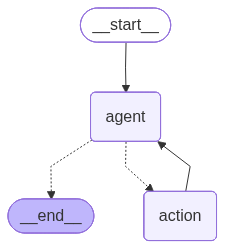

DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


human

What is todays date

ai

{'refusal': None}


tool

2026-04-24

ai

Today's date is April 24, 2026.

{'refusal': None}


In [51]:
@tool
def get_current_date_tool():
    """Returns the current date in YYY-MM-DD format. Used to get dates for hotel or flight booking"""
    return date.today().isoformat()

app_current_date = build_graph_one_tool([get_current_date_tool])

#prepare input
prompt = "What is todays date"
output, history = app_call(app_current_date,  prompt)

# LEVERAGE LANGGRAPH TO PERFORM HOTEL SEARCH USING RAPIDAPI & `ToolNode`

In [52]:
# Load RapidAPI key from environment
RAPIDAPI_KEY = os.getenv("RAPIDAPI_KEY")
print(f"RapidAPI Key loaded: {'yes' if RAPIDAPI_KEY else 'no'}")

RapidAPI Key loaded: yes


In [56]:
# RapidAPI-based hotel search client
import requests

def search_hotels(city: str, checkin_date: str, checkout_date: str):
    url = "https://booking-com.p.rapidapi.com/v1/hotels/search"

    headers = {
        "X-RapidAPI-Key": RAPIDAPI_KEY,
        "X-RapidAPI-Host": "booking-com.p.rapidapi.com"
    }

    params = {
        "checkin_date": checkin_date,
        "checkout_date": checkout_date,
        "units": "metric",
        "adults_number": 2,
        "room_number": 1,
        "dest_type": "city",
        "dest_id": "-2092174",
        "order_by": "popularity",
        "locale": "en-gb"
    }

    if not RAPIDAPI_KEY:
        return [{"error": "RAPIDAPI_KEY is not set"}]

    response = requests.get(url, headers=headers, params=params, timeout=20)
    data = response.json()

    results = []
    if "result" in data:
        for hotel in data["result"][:5]:
            results.append({
                "name": hotel.get("hotel_name"),
                "price": hotel.get("min_total_price"),
                "rating": hotel.get("review_score"),
                "address": hotel.get("address")
            })

    return str(results)


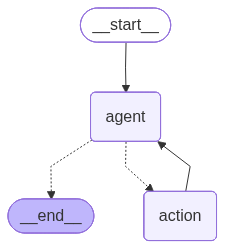

In [57]:
@tool
def hotel_search_tool(city: str, checkin_date: str, checkout_date: str):
    """Search hotels using RapidAPI Booking.com"""
    return search_hotels(city, checkin_date, checkout_date)


# Create Hotel Search Tools List
tools_list_full = [
    get_current_date_tool,
    hotel_search_tool,
]

app_hotel_search = build_graph_one_tool(tools_list_full)

In [58]:
# Prepare your input
prompt = "Find hotel options in Paris from 2026-06-01 to 2026-06-05"
output, history = app_call(app_hotel_search, prompt)

print("\n==================== OUTPUT ====================")
print(output)

print("\n==================== HISTORY ===================")
print(history)

DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


human

Find hotel options in Paris from 2026-06-01 to 2026-06-05

ai

{'refusal': None}


...

tool

2026-04-24

ai

I couldn't find any hotel options in Paris for the dates June 1 to June 5, 2026. It's possible that the availability is not yet listed, as that date is quite far in the future. If you have other dates or destinations in mind, please let me know!

{'refusal': None}

==================== OUTPUT ====================
I couldn't find any hotel options in Paris for the dates June 1 to June 5, 2026. It's possible that the availability is not yet listed, as that date is quite far in the future. If you have other dates or destinations in mind, please let me know!

==================== HISTORY ===================
{'messages': [HumanMessage(content='Find hotel options in Paris from 2026-06-01 to 2026-06-05', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 109, 'total_tokens': 175, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f9565ce549', 'id': 'chatcmpl-DYEr

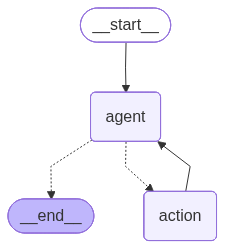

DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


human

I am planning a trip to New York from 2026-06-01 to 2026-06-04. Please fetch travel advisories and suggest hotel options.

ai

{'refusal': None}


...

tool

[]

ai

### Travel Advisories for New York (June 2026)

1. **Travel Ban Lifted Amid Winter Weather (February 23, 2026)**  
   - Source: [NYC Mayor's Office](https://www.nyc.gov/mayors-office/news/2026/02/mayor-mamdani-announces-lift-of-travel-ban--nyc-public-schools-t)  
   - NYC Mayor Mamdani announced the end of a travel ban due to severe winter weather conditions. While the ban has been lifted, the mayor advises caution while driving and recommends using public transportation. A local state of emergency remains, along with a blizzard warning.

2. **Safety Tips for Tourists in New York (2026)**  
   - Source: [Real's Tours NYC](https://realstoursnyc.com/en/post/120/is-it-safe-to-travel-to-new-york-in-2026-the-ultimate-tourist-safety-guide/)  
   - Be aware of common scams involving Broadway ticket hawkers, costumed characters, and aggressive "free" CD salespeople. Use official public transport and always keep an eye on your belongings. It's advisable to have health insurance, be cautious with your drinks, and avoid looking lost in busy areas.

3. **Traveler Advisories Overview (2026)**  
   - Source: [NY State Department of Transportation](https://www.dot.ny.gov/news/traveler-advisories/2026)  
   - Lane closures and road conditions may change as various construction and maintenance activities are scheduled throughout the state. Ensure to check for updates before travel.

### Hotel Options in New York From June 1 to June 4, 2026

Unfortunately, I wasn't able to retrieve specific hotel options for your stay in New York during that period. However, you can consider the following popular areas for accommodations:

1. **Manhattan**: Central location with numerous hotels and attractions nearby.
2. **Brooklyn**: Trendy neighborhoods with a vibrant food scene and close proximity to Manhattan.
3. **Queens**: More affordable options and diverse cultural experiences.

For a smoother booking experience, consider using hotel booking websites like Booking.com or Expedia where you can easily compare prices, locations, and guest reviews.

{'refusal': None}


In [59]:
tools = [hotel_search_tool, tavily_search_tool]

app_travel_agent = build_graph_one_tool(tools)

# Prepare your input
prompt = "I am planning a trip to New York from 2026-06-01 to 2026-06-04. Please fetch travel advisories and suggest hotel options."
output, history = app_call(app_travel_agent, prompt)

In [60]:
print_markdown(output)

### Travel Advisories for New York (June 2026)

1. **Travel Ban Lifted Amid Winter Weather (February 23, 2026)**  
   - Source: [NYC Mayor's Office](https://www.nyc.gov/mayors-office/news/2026/02/mayor-mamdani-announces-lift-of-travel-ban--nyc-public-schools-t)  
   - NYC Mayor Mamdani announced the end of a travel ban due to severe winter weather conditions. While the ban has been lifted, the mayor advises caution while driving and recommends using public transportation. A local state of emergency remains, along with a blizzard warning.

2. **Safety Tips for Tourists in New York (2026)**  
   - Source: [Real's Tours NYC](https://realstoursnyc.com/en/post/120/is-it-safe-to-travel-to-new-york-in-2026-the-ultimate-tourist-safety-guide/)  
   - Be aware of common scams involving Broadway ticket hawkers, costumed characters, and aggressive "free" CD salespeople. Use official public transport and always keep an eye on your belongings. It's advisable to have health insurance, be cautious with your drinks, and avoid looking lost in busy areas.

3. **Traveler Advisories Overview (2026)**  
   - Source: [NY State Department of Transportation](https://www.dot.ny.gov/news/traveler-advisories/2026)  
   - Lane closures and road conditions may change as various construction and maintenance activities are scheduled throughout the state. Ensure to check for updates before travel.

### Hotel Options in New York From June 1 to June 4, 2026

Unfortunately, I wasn't able to retrieve specific hotel options for your stay in New York during that period. However, you can consider the following popular areas for accommodations:

1. **Manhattan**: Central location with numerous hotels and attractions nearby.
2. **Brooklyn**: Trendy neighborhoods with a vibrant food scene and close proximity to Manhattan.
3. **Queens**: More affordable options and diverse cultural experiences.

For a smoother booking experience, consider using hotel booking websites like Booking.com or Expedia where you can easily compare prices, locations, and guest reviews.

In [ ]:
def travel_agent_chat(user_input: str, history=None):
    tools_used = []
    stream = app_travel_agent.stream(
        {"messages": [HumanMessage(content=user_input)]},
        config={"recursion_limit": 15, "configurable": {"thread_id": str(uuid.uuid4())}},
    )

    # 1) Stream in tool calls and model tokens
    for chunk in stream:
        _, node = next(iter(chunk.items()))
        if isinstance(node, dict) and "messages" in node:
            for msg in node["messages"]:
                if isinstance(msg, ToolMessage):
                    if msg.name not in tools_used:
                        tools_used.append(msg.name)
                    yield f"\n\n **Tool:** {msg.name}\n{msg.content}\n\n—\n\n"
                elif isinstance(msg, AIMessage) and msg.content:
                    yield msg.content

    # 2) After streaming completes, yield a recap
    if tools_used:
        yield f"\n\n**Tools used this session:** {', '.join(tools_used)} \n\n — \n\n {msg.content}"


travel_chatbot_interface = gr.ChatInterface(
    fn=travel_agent_chat,
    chatbot=gr.Chatbot(
        height=650,
        label="AI Travel Agent",

       
    ),
    textbox=gr.Textbox(
        placeholder="Plan your trip! Ask about attractions, travel advisories, and hotels...", container=False, scale=7
    ),
    title="✈️ LangGraph AI Travel Agent 🌍",
    description="Your stateful travel assistant…",
    examples=[
        ["What are the top 3 tourist attractions in Tokyo?"],
        ["Share the latest travel advisories for New York."],
        ["Find hotel options in Paris from 2026-06-01 to 2026-06-05."],
    ],
    cache_examples=False,
)

travel_chatbot_interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)
